# AI for Communication and Marketing - Lab Exam Part 1


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)


---
# Task A - Data Audit & Quality


## A.1 Load the dataset


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/marketing_campaign.csv", sep=";", encoding="utf-8-sig")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 2240 rows x 27 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


## A.2 Variable types


In [34]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%Y-%m-%d")

binary_flags = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4",
                "AcceptedCmp5", "Complain", "Response"]
categorical_cols = ["Education", "Marital_Status"] + binary_flags
datetime_cols = ["Dt_Customer"]
numerical_cols = [c for c in df.columns if c not in categorical_cols + datetime_cols + ["ID"]]

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
audit["family"] = np.where(audit.index.isin(numerical_cols), "Numerical",
                  np.where(audit.index.isin(categorical_cols), "Categorical",
                  np.where(audit.index.isin(datetime_cols), "Datetime", "ID")))
audit


,dtype,n_missing,pct_missing,n_unique,family
ID,int64,0,0.00,2240,ID
Year_Birth,int64,0,0.00,59,Numerical
Education,object,0,0.00,5,Categorical
Marital_Status,object,0,0.00,8,Categorical
Income,float64,24,1.07,1974,Numerical
Kidhome,int64,0,0.00,3,Numerical
Teenhome,int64,0,0.00,3,Numerical
Dt_Customer,datetime64[ns],0,0.00,663,Datetime
Recency,int64,0,0.00,100,Numerical
MntWines,int64,0,0.00,776,Numerical


**Audit findings**

- Only `Income` has missing values (24 rows, ~1% of the dataset).
- No duplicate rows.


In [35]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Date range of enrollment: {df['Dt_Customer'].min().date()} to {df['Dt_Customer'].max().date()}")


Duplicate rows: 0
Date range of enrollment: 2012-07-30 to 2014-06-29


## A.3 Outlier detection

I inspect the distributions of the most important numerical variables and the level set of categorical ones. The plots below highlight three issues worth addressing.


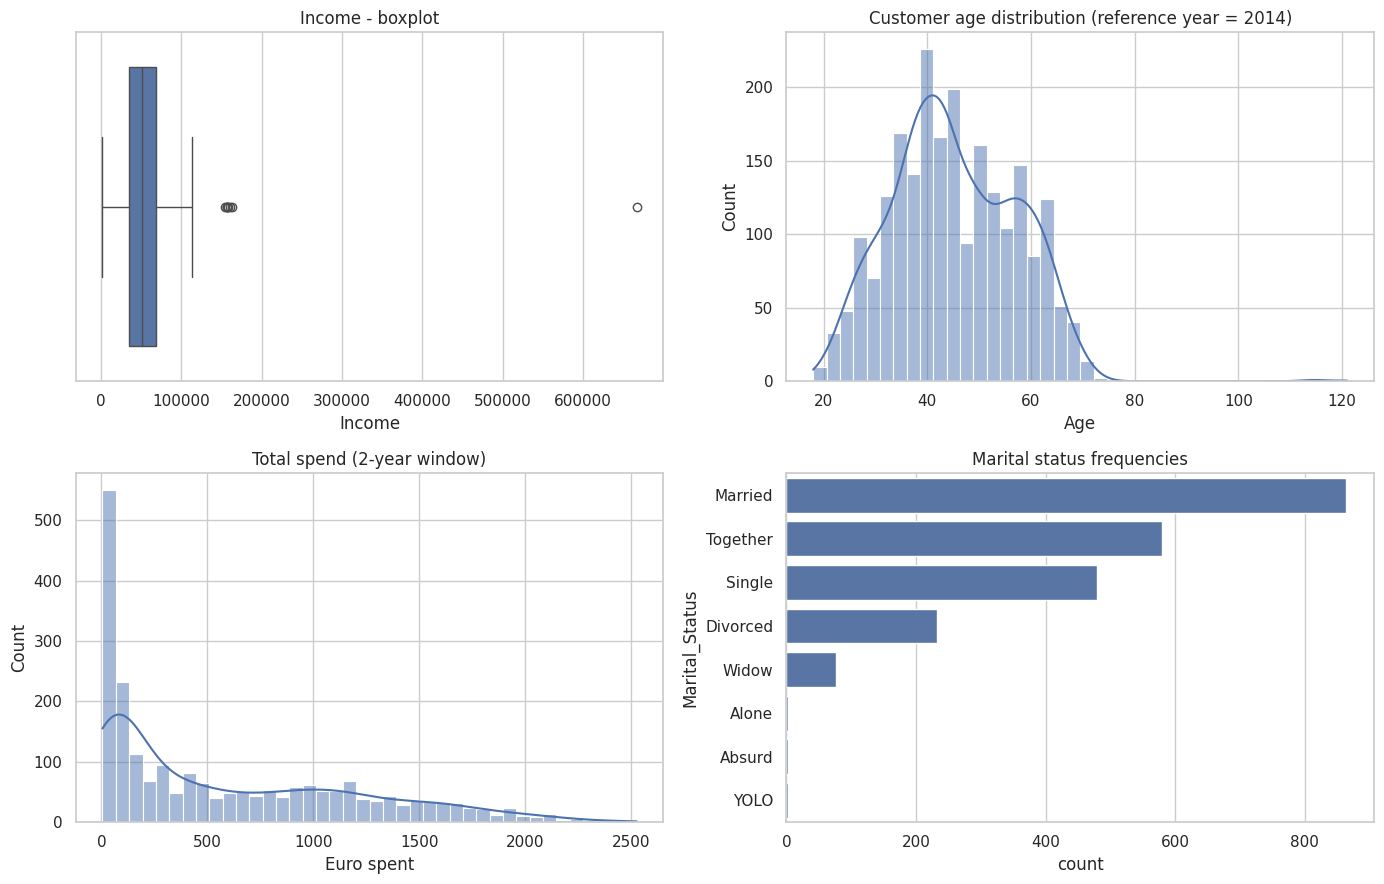

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(x=df["Income"], ax=axes[0, 0])
axes[0, 0].set_title("Income - boxplot")

sns.histplot(2014 - df["Year_Birth"], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Customer age distribution (reference year = 2014)")
axes[0, 1].set_xlabel("Age")

total_spend = df[["MntWines", "MntFruits", "MntMeatProducts",
                  "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].sum(axis=1)
sns.histplot(total_spend, bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Total spend (2-year window)")
axes[1, 0].set_xlabel("Euro spent")

sns.countplot(y="Marital_Status", data=df,
              order=df["Marital_Status"].value_counts().index, ax=axes[1, 1])
axes[1, 1].set_title("Marital status frequencies")

plt.tight_layout()
plt.show()


In [37]:
print("Top 5 Income values:")
print(df["Income"].nlargest(5).to_string())
print("\nOldest customers (lowest Year_Birth):")
print(df["Year_Birth"].nsmallest(5).to_string())
print("\nMarital_Status counts:")
print(df["Marital_Status"].value_counts().to_string())


Top 5 Income values:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0

Oldest customers (lowest Year_Birth):
239     1893
339     1899
192     1900
1950    1940
424     1941

Marital_Status counts:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2


**Anomalies identified**

1. **Income outlier.** One customer reports an income of `666,666` - almost 4x the next highest value (`162,397`).
2. **Implausible birth years.** Three customers have `Year_Birth` of 1893, 1899 and 1900 - implying ages above 110, which is biologically near-impossible.
3. **Junk marital statuses.** `YOLO` (2 rows) and `Absurd` (2 rows) are clearly invalid responses. `Alone` (3 rows) is semantically equivalent to `Single`.


## A.4 Cleaning strategy

| Issue | Decision | Why |
|---|---|---|
| `Income` has 24 missing values (~1%) | **Median imputation** | The income distribution is right-skewed and the missing share is tiny - median preserves the central tendency without injecting an artificial mean. Dropping 24 rows would also work but median imputation keeps every customer in the segmentation. |
| `Income = 666,666` (1 row) | **Drop** | The value is implausible and would single-handedly dominate the scaling of any distance-based model (K-Means). |
| `Year_Birth ≤ 1900` (3 rows) | **Drop** | Three rows in 2,240 (0.13%) - too few to bother imputing and clearly invalid. |
| `Marital_Status ∈ {YOLO, Absurd}` (4 rows) | **Drop** | Junk responses with no meaningful business interpretation. |
| `Marital_Status = Alone` (3 rows) | **Map to `Single`** | Semantic duplicate. |
| Duplicates | **None to remove** | The audit showed zero duplicate rows. |

I will work on a copy `df_clean` and keep the raw `df` available for reference.


In [38]:
df_clean = df.copy()

# Drop implausible birth years
df_clean = df_clean[df_clean["Year_Birth"] >= 1940].copy()

# Marital status: drop junk and consolidate
df_clean = df_clean[~df_clean["Marital_Status"].isin(["YOLO", "Absurd"])].copy()
df_clean["Marital_Status"] = df_clean["Marital_Status"].replace({"Alone": "Single"})

# Income: median imputation, then winsorize at the 99th percentile
df_clean = df_clean[df_clean["Income"] != 666666].copy()
median_income = df_clean["Income"].median()
df_clean["Income"] = df_clean["Income"].fillna(median_income)

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}  (removed {len(df) - len(df_clean)})")
print(f"Income median (used for imputation): {median_income:,.0f}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")


Rows before cleaning: 2240
Rows after cleaning:  2232  (removed 8)
Income median (used for imputation): 51,371
Remaining missing values: 0


## A.5 Post-cleaning verification

Same plots, after cleaning.


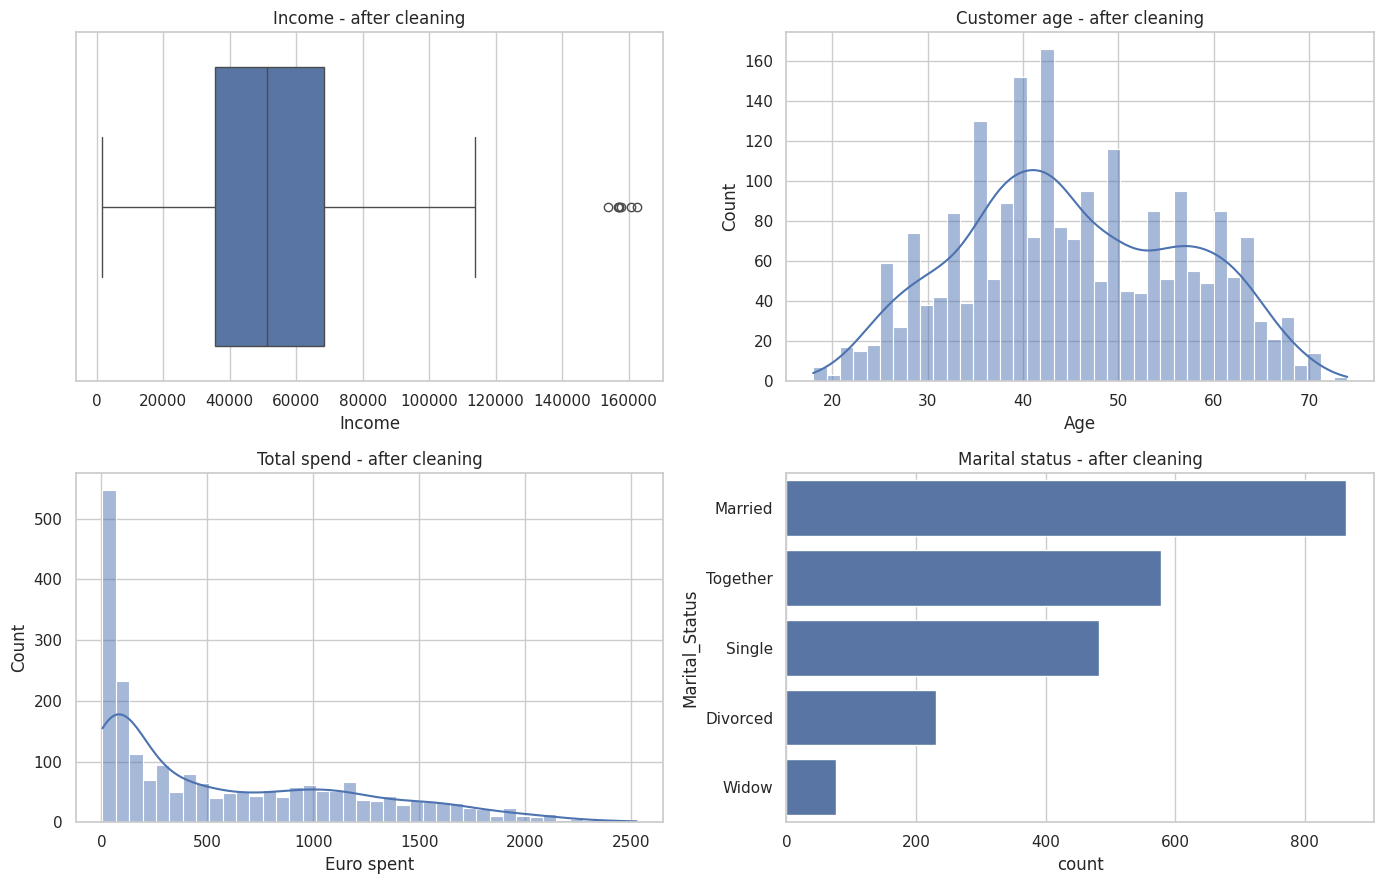

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(x=df_clean["Income"], ax=axes[0, 0])
axes[0, 0].set_title("Income - after cleaning")

sns.histplot(2014 - df_clean["Year_Birth"], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Customer age - after cleaning")
axes[0, 1].set_xlabel("Age")

total_spend_clean = df_clean[["MntWines", "MntFruits", "MntMeatProducts",
                              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].sum(axis=1)
sns.histplot(total_spend_clean, bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Total spend - after cleaning")
axes[1, 0].set_xlabel("Euro spent")

sns.countplot(y="Marital_Status", data=df_clean,
              order=df_clean["Marital_Status"].value_counts().index, ax=axes[1, 1])
axes[1, 1].set_title("Marital status - after cleaning")

plt.tight_layout()
plt.show()


The Income outlier is removed, customer ages are realistic, and only valid marital statuses remain.

---
# Task B - Exploratory Data Analysis

I start by engineering a few derived features that make the analysis more readable.


## B.1 Feature engineering

| Feature | Definition |
|---|---|
| `Age` | `2014 - Year_Birth` (the latest enrollment is 2014; using a fixed reference avoids dependence on the analysis date) |
| `TotalSpend` | Sum of the six `Mnt*` columns (total spend over the 2-year window) |
| `Children` | `Kidhome + Teenhome` |
| `HasChildren` | 1 if `Children > 0`, else 0 |
| `TotalPurchases` | Sum of web + catalog + store + deals purchases |
| `AcceptedCmpTotal` | Sum of the five campaign acceptance flags |


In [40]:
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
purchase_cols = ["NumWebPurchases", "NumCatalogPurchases",
                 "NumStorePurchases", "NumDealsPurchases"]
cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
            "AcceptedCmp4", "AcceptedCmp5"]

df_clean["Age"] = 2014 - df_clean["Year_Birth"]
df_clean["TotalSpend"] = df_clean[mnt_cols].sum(axis=1)
df_clean["Children"] = df_clean["Kidhome"] + df_clean["Teenhome"]
df_clean["HasChildren"] = (df_clean["Children"] > 0).astype(int)
df_clean["TotalPurchases"] = df_clean[purchase_cols].sum(axis=1)
df_clean["AcceptedCmpTotal"] = df_clean[cmp_cols].sum(axis=1)
df_clean["IncomeBand"] = pd.qcut(df_clean["Income"], 5,
                                  labels=["Low", "Lower-Mid", "Mid", "Upper-Mid", "High"])

df_clean[["Age", "TotalSpend", "Children", "TotalPurchases", "AcceptedCmpTotal"]].describe().round(1)


,Age,TotalSpend,Children,TotalPurchases,AcceptedCmpTotal
count,2232.0,2232.0,2232.0,2232.0,2232.0
mean,45.1,605.6,1.0,14.9,0.3
std,11.7,602.1,0.8,7.7,0.7
min,18.0,5.0,0.0,0.0,0.0
25%,37.0,69.0,0.0,8.0,0.0
50%,44.0,396.0,1.0,15.0,0.0
75%,55.0,1044.2,1.0,21.0,0.0
max,74.0,2525.0,3.0,44.0,4.0


## B.2 Correlation: socio-demographics vs. total spending

I compute Pearson correlations of every numerical socio-demographic feature against `TotalSpend` and visualize the broader correlation matrix to spot multicollinearity that will matter later in clustering.


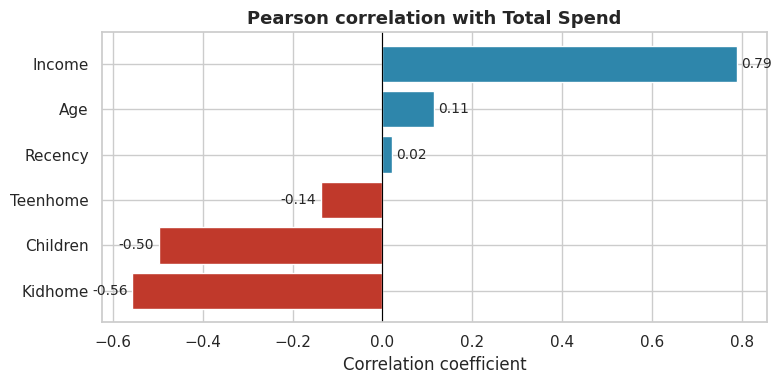

In [41]:
socio_cols = ["Age", "Income", "Kidhome", "Teenhome", "Children", "Recency"]
corr_with_spend = df_clean[socio_cols + ["TotalSpend"]].corr()["TotalSpend"].drop("TotalSpend").sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#C0392B" if v < 0 else "#2E86AB" for v in corr_with_spend.values]
ax.barh(corr_with_spend.index, corr_with_spend.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson correlation with Total Spend", fontsize=13, weight="bold")
ax.set_xlabel("Correlation coefficient")
for i, v in enumerate(corr_with_spend.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=10)
plt.tight_layout()
plt.show()


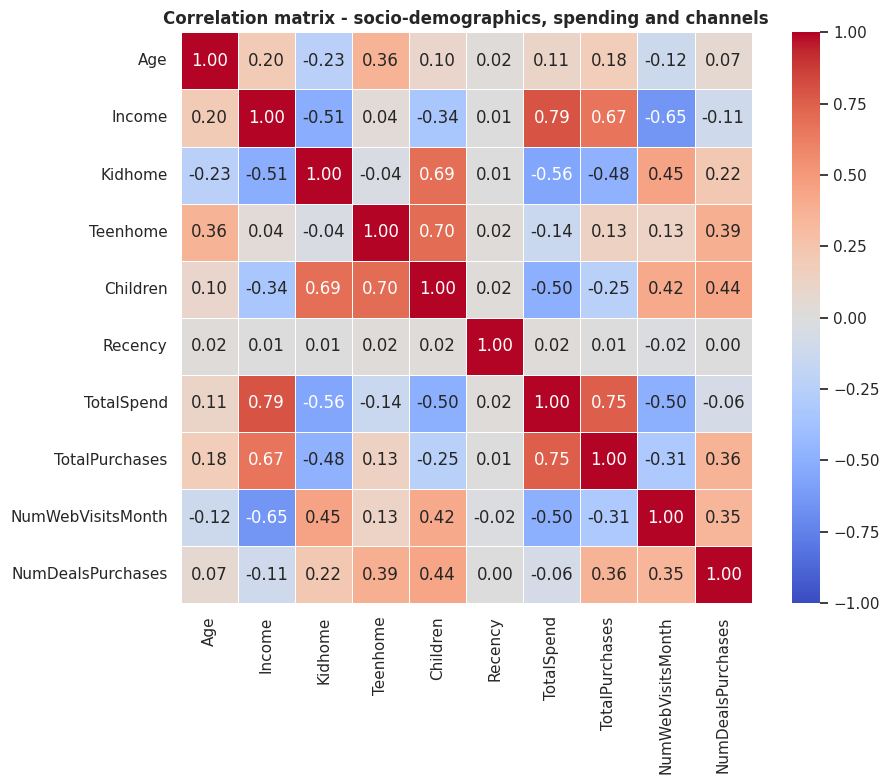

In [42]:
eda_cols = socio_cols + ["TotalSpend", "TotalPurchases",
                         "NumWebVisitsMonth", "NumDealsPurchases"]
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[eda_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation matrix - socio-demographics, spending and channels", weight="bold")
plt.tight_layout()
plt.show()


**Reading the matrix**

- `Income` is by far the strongest positive predictor of `TotalSpend` (**r = 0.67**) - the obvious finding.
- `Children` (and its components `Kidhome`, `Teenhome`) is the strongest *negative* predictor of spend (**r = −0.50**).
- `NumWebVisitsMonth` is also strongly negatively correlated with `TotalSpend` (**r = −0.50**) - counter-intuitive and worth a closer look.
- `Age` carries almost no signal (**r = 0.11**), which is unusual.


## B.3 Distribution of purchases across channels

How do customers actually buy? I compare the four channels both at the aggregate level and at the per-customer level.


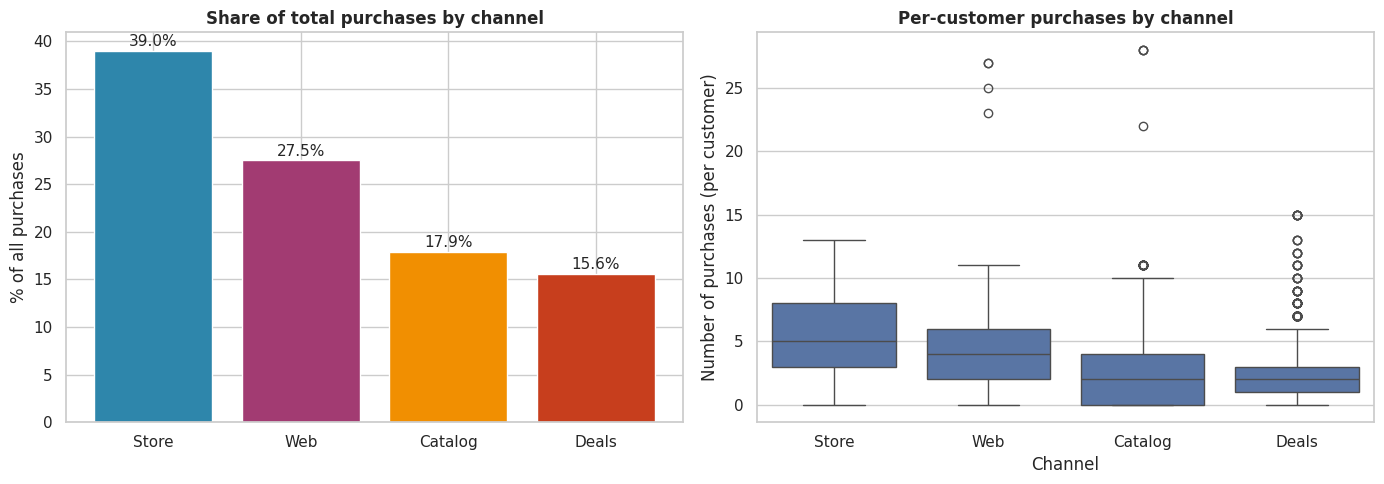

In [43]:
channel_totals = df_clean[purchase_cols].sum().sort_values(ascending=False)
channel_share = (channel_totals / channel_totals.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

short_labels = [c.replace("Num", "").replace("Purchases", "") for c in channel_share.index]
axes[0].bar(short_labels, channel_share.values,
            color=["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"])
axes[0].set_title("Share of total purchases by channel", weight="bold")
axes[0].set_ylabel("% of all purchases")
for i, v in enumerate(channel_share.values):
    axes[0].text(i, v + 0.5, f"{v}%", ha="center", fontsize=11)

melted = df_clean[purchase_cols].melt(var_name="Channel", value_name="Purchases")
melted["Channel"] = melted["Channel"].str.replace("Num", "").str.replace("Purchases", "")
sns.boxplot(data=melted, x="Channel", y="Purchases",
            order=["Store", "Web", "Catalog", "Deals"], ax=axes[1])
axes[1].set_title("Per-customer purchases by channel", weight="bold")
axes[1].set_ylabel("Number of purchases (per customer)")

plt.tight_layout()
plt.show()


**Channel takeaways**

- **Store** dominates (~39% of all purchases) - physical retail still anchors the business.
- **Web** is the second channel (~27%), followed by **Catalog** and **Deals**.
- Catalog has the smallest *footprint* but the most uniform usage - there is a focused, smaller segment of catalog buyers I will examine next.


## B.4 Hidden trends

The correlation matrix already pointed some unusual signals.


### Trend 1 - No children = good




Spend by number of children at home:
          Avg Spend (EUR)  Customers  Share of base
Children                                           
0                  1105.0        635           28.4
1                   474.0       1123           50.3
2                   246.0        421           18.9
3                   275.0         53            2.4


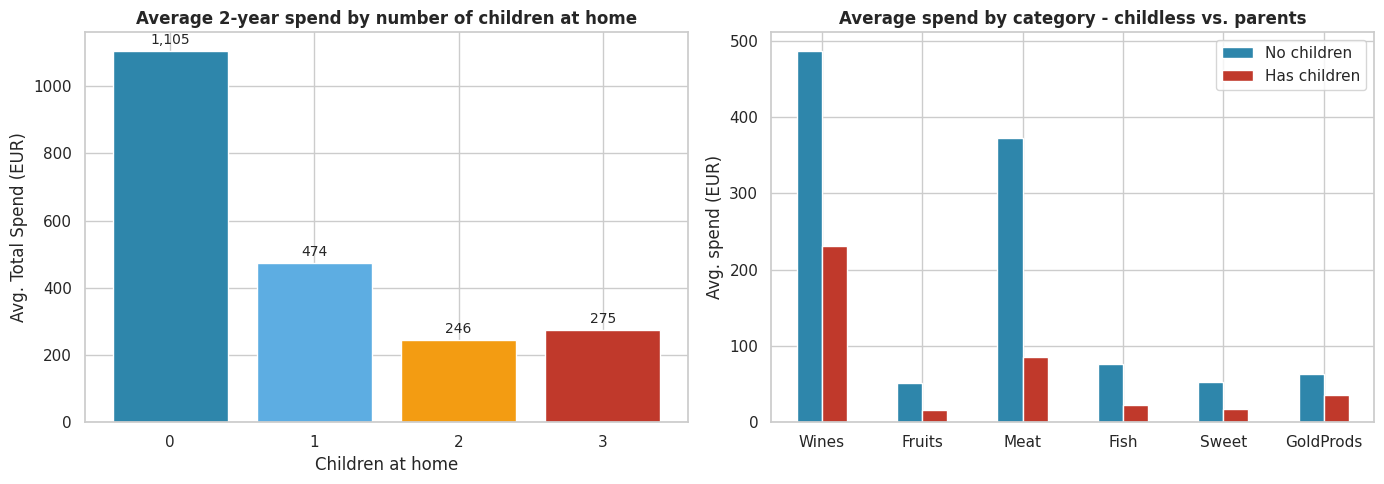

In [44]:
# Spend by household composition
spend_by_kids = df_clean.groupby("Children")["TotalSpend"].agg(["mean", "count"]).round(0)
spend_by_kids.columns = ["Avg Spend (EUR)", "Customers"]
spend_by_kids["Share of base"] = (spend_by_kids["Customers"] / spend_by_kids["Customers"].sum() * 100).round(1)
print("Spend by number of children at home:")
print(spend_by_kids)

# Category-level: how does each product behave?
cat_split = df_clean.groupby("HasChildren")[mnt_cols].mean().round(0)
cat_split.index = ["No children", "Has children"]
cat_split.columns = [c.replace("Mnt", "").replace("Products", "") for c in cat_split.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(spend_by_kids.index.astype(str), spend_by_kids["Avg Spend (EUR)"],
            color=["#2E86AB", "#5DADE2", "#F39C12", "#C0392B"])
axes[0].set_title("Average 2-year spend by number of children at home", weight="bold")
axes[0].set_xlabel("Children at home")
axes[0].set_ylabel("Avg. Total Spend (EUR)")
for i, v in enumerate(spend_by_kids["Avg Spend (EUR)"].values):
    axes[0].text(i, v + 20, f"{int(v):,}", ha="center", fontsize=10)

cat_split.T.plot(kind="bar", ax=axes[1], color=["#2E86AB", "#C0392B"])
axes[1].set_title("Average spend by category - childless vs. parents", weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg. spend (EUR)")
axes[1].legend(title="")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()


Customers with **no children at home** spend on average **4.5x** more than customers with two children - even though both groups span all income levels. The gap is largest for premium categories (wine, meat) and small for low-ticket categories (fruits, sweets).

**Why it matters commercially.** Roughly **over 70%** of the customer base has at least one child at home, yet they account for a tiny share of revenue. Either parents are buying premium goods elsewhere (likely), or the product mix is mispriced for them. Both readings unlock revenue.

**HOW TO USE IT** A targeted **family-bundle campaign** (premium meats and wines packaged with kid-friendly add-ons (sweets, fruits) and a parent-friendly delivery slot) could lift the parent segment's average spend even modestly and still represent a BIG uplift, since parents are over 70% of the base.


### Trend 2 - The Catalog

When I assign each customer their dominant channel (whichever among store, web, catalog has the most purchases), **catalog-first customers have an Average Order Value more than double that of web-first or store-first customers**. They are a small group (~7% of the base), but they pull above their weight in revenue.

**Why it matters commercially.** The catalog is the cheapest premium-acquisition channel - it self-selects high-value customers without any algorithmic targeting. Doubling catalog mailings to similar customers is the lowest-risk growth lever in the data.


             Customers  AvgOrderValue  AvgTotalSpend  % of base
MainChannel                                                    
Catalog            158           67.0         1305.5        7.1
Store             1476           31.1          554.7       66.1
Web                598           29.9          546.3       26.8


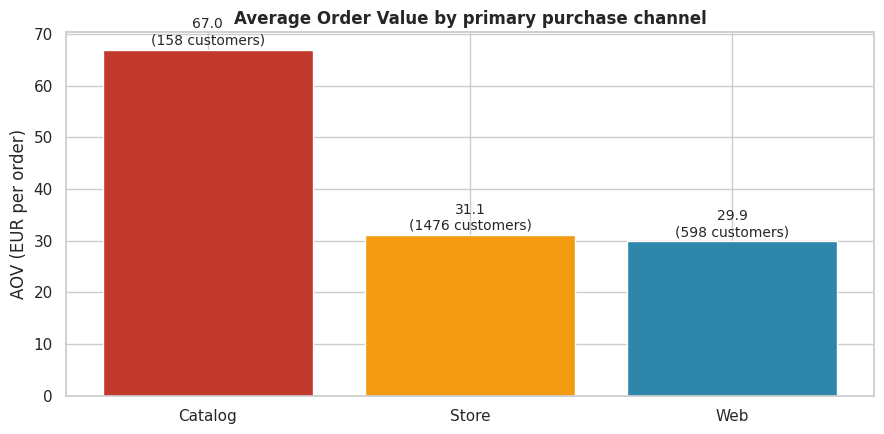

In [45]:
# Identify dominant channel
channel_map = {"NumWebPurchases": "Web", "NumCatalogPurchases": "Catalog",
               "NumStorePurchases": "Store"}
df_clean["MainChannel"] = df_clean[list(channel_map)].idxmax(axis=1).map(channel_map)
df_clean["AOV"] = df_clean["TotalSpend"] / df_clean["TotalPurchases"].replace(0, np.nan)

aov_by_channel = df_clean.groupby("MainChannel").agg(
    Customers=("ID", "count"),
    AvgOrderValue=("AOV", "mean"),
    AvgTotalSpend=("TotalSpend", "mean"),
).round(1)
aov_by_channel["% of base"] = (aov_by_channel["Customers"] / len(df_clean) * 100).round(1)
aov_by_channel = aov_by_channel.sort_values("AvgOrderValue", ascending=False)
print(aov_by_channel)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(aov_by_channel.index, aov_by_channel["AvgOrderValue"],
       color=["#C0392B", "#F39C12", "#2E86AB"])
ax.set_title("Average Order Value by primary purchase channel", weight="bold")
ax.set_ylabel("AOV (EUR per order)")
for i, (label, row) in enumerate(aov_by_channel.iterrows()):
    ax.text(i, row["AvgOrderValue"] + 1,
            f"{row['AvgOrderValue']:.1f}\n({int(row['Customers'])} customers)",
            ha="center", fontsize=10)
plt.tight_layout()
plt.show()


But to which group should I recommend catalog?

In [46]:
catalog_buyers = df_clean[df_clean["MainChannel"] == "Catalog"]
other_buyers = df_clean[df_clean["MainChannel"] != "Catalog"]

profile_compare = pd.DataFrame({
    "Catalog-first": [
        len(catalog_buyers),
        f"{catalog_buyers['Income'].mean():,.0f}",
        f"{catalog_buyers['Children'].mean():.2f}",
        f"{(catalog_buyers['Children'] == 0).mean() * 100:.1f}%",
        f"{catalog_buyers['Age'].mean():.1f}",
        f"{catalog_buyers['TotalSpend'].mean():,.0f}",
        f"{catalog_buyers['AOV'].mean():.1f}",
    ],
    "All other channels": [
        len(other_buyers),
        f"{other_buyers['Income'].mean():,.0f}",
        f"{other_buyers['Children'].mean():.2f}",
        f"{(other_buyers['Children'] == 0).mean() * 100:.1f}%",
        f"{other_buyers['Age'].mean():.1f}",
        f"{other_buyers['TotalSpend'].mean():,.0f}",
        f"{other_buyers['AOV'].mean():.1f}",
    ],
}, index=["Customers", "Avg Income (EUR)", "Avg Children at home",
          "% with no children", "Avg Age", "Avg Total Spend (EUR)",
          "Avg Order Value (EUR)"])
print("Catalog-first vs. the rest of the customer base")
print(profile_compare.to_string())

Catalog-first vs. the rest of the customer base
                      Catalog-first All other channels
Customers                       158               2074
Avg Income (EUR)             72,133             50,399
Avg Children at home           0.35               1.00
% with no children            70.9%              25.2%
Avg Age                        48.3               44.9
Avg Total Spend (EUR)         1,306                552
Avg Order Value (EUR)          67.0               30.7


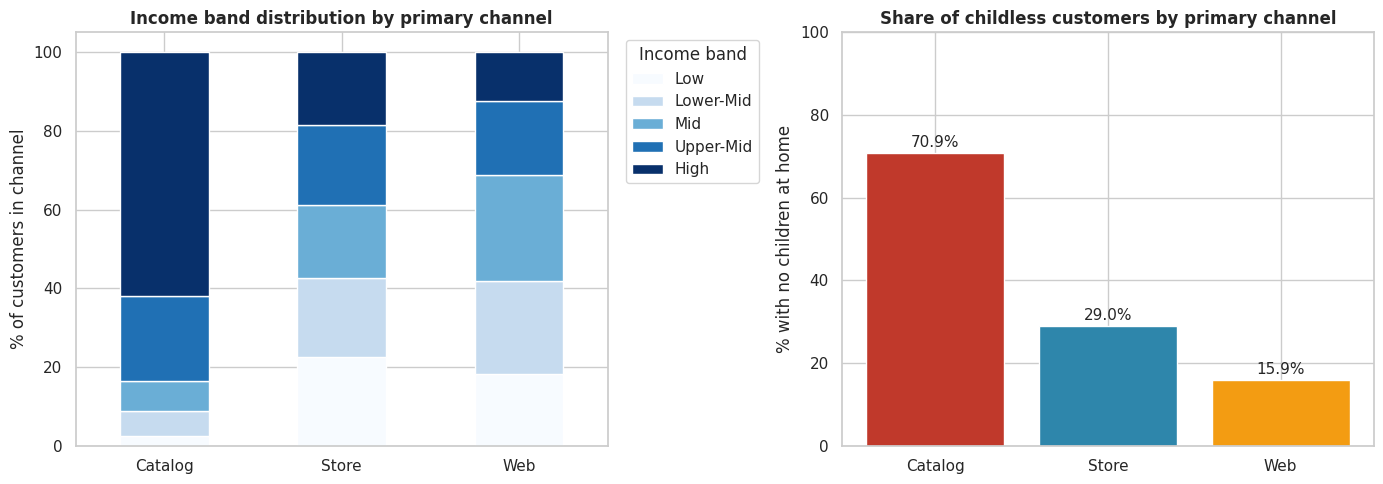

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

income_dist = pd.crosstab(df_clean["MainChannel"], df_clean["IncomeBand"],
                          normalize="index") * 100
income_dist = income_dist.loc[["Catalog", "Store", "Web"]]
income_dist.plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues")
axes[0].set_title("Income band distribution by primary channel", weight="bold")
axes[0].set_ylabel("% of customers in channel")
axes[0].set_xlabel("")
axes[0].legend(title="Income band", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

children_dist = df_clean.groupby("MainChannel").apply(
    lambda x: (x["Children"] == 0).mean() * 100, include_groups=False
).reindex(["Catalog", "Store", "Web"])
axes[1].bar(children_dist.index, children_dist.values,
            color=["#C0392B", "#2E86AB", "#F39C12"])
axes[1].set_title("Share of childless customers by primary channel", weight="bold")
axes[1].set_ylabel("% with no children at home")
axes[1].set_ylim(0, 100)
for i, v in enumerate(children_dist.values):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [48]:
top_quintile_threshold = df_clean["Income"].quantile(0.8)

lookalike_mask = (df_clean["Income"] >= top_quintile_threshold) & (df_clean["Children"] == 0)
already_catalog = (df_clean["MainChannel"] == "Catalog") & lookalike_mask
addressable = lookalike_mask & (df_clean["MainChannel"] != "Catalog")

print(f"Look-alike rule: Income >= 80th percentile (>= {top_quintile_threshold:,.0f} EUR) AND no children at home\n")
print(f"Customers matching the rule:        {lookalike_mask.sum():>5}")
print(f"  - already catalog-first:          {already_catalog.sum():>5}")
print(f"  - addressable for catalog campaign:{addressable.sum():>5}")
print(f"\nAvg Total Spend of the addressable group: {df_clean.loc[addressable, 'TotalSpend'].mean():,.0f} EUR")
print(f"Avg Total Spend of the rest of the base:  {df_clean.loc[~lookalike_mask, 'TotalSpend'].mean():,.0f} EUR")

Look-alike rule: Income >= 80th percentile (>= 71,611 EUR) AND no children at home

Customers matching the rule:          329
  - already catalog-first:             83
  - addressable for catalog campaign:  246

Avg Total Spend of the addressable group: 1,465 EUR
Avg Total Spend of the rest of the base:  455 EUR


---
# Task C - RFM Calculation & Heuristic Segmentation

I now translate the cleaned dataset into an **RFM** view of the customer base:

- **Recency (R)** - already provided in `Recency`: number of days since the customer's last purchase.
- **Frequency (F)** - `NumWebPurchases + NumCatalogPurchases + NumStorePurchases + NumDealsPurchases`, i.e. the total number of orders across all channels in the 2-year window.
- **Monetary (M)** - `TotalSpend`, the sum of all category-level spending in the 2-year window.

I score each dimension on a **1–5 quintile scale** and combine the scores into named segments.


In [49]:
rfm = df_clean[["ID"]].copy()
rfm["Recency"] = df_clean["Recency"]
rfm["Frequency"] = df_clean["TotalPurchases"]
rfm["Monetary"] = df_clean["TotalSpend"]

rfm[["Recency", "Frequency", "Monetary"]].describe().round(1)


,Recency,Frequency,Monetary
count,2232.0,2232.0,2232.0
mean,49.2,14.9,605.6
std,28.9,7.7,602.1
min,0.0,0.0,5.0
25%,24.0,8.0,69.0
50%,49.5,15.0,396.0
75%,74.0,21.0,1044.2
max,99.0,44.0,2525.0


## C.1 Quintile scoring (1–5)

Recency uses *reverse* labels so that **5 = most recent** (best). Frequency and Monetary use ascending labels so that **5 = highest** (best).


In [50]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"] * 100 + rfm["F_Score"] * 10 + rfm["M_Score"]
rfm.head()


,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,5524,58,25,1617,3,5,5,355
1,2174,38,6,27,4,1,1,411
2,4141,26,21,776,4,4,4,444
3,6182,26,8,53,4,2,1,421
4,5324,94,19,422,1,4,3,143


## C.2 Segment definition

I define **five** named segments using the combined R, F and M scores. The thresholds are chosen so that each segment has a distinct marketing meaning and is large enough to be actionable.

| Segment | Rule | Marketing meaning |
|---|---|---|
| **Champions** | R ≥ 4 **and** F ≥ 4 **and** M ≥ 4 | Recently active, frequent, high-spending - the top tier |
| **Loyal Customers** | F ≥ 4 **and** M ≥ 3, but not Champions | Consistent, valuable buyers; nurture for retention |
| **Potential Loyalists** | R ≥ 4 **and** F ≤ 3 | Recent buyers with low frequency yet - onboarding/cross-sell |
| **At Risk** | R ≤ 2 **and** M ≥ 3 | Used to spend well but haven't bought lately - win-back |
| **Hibernating** | Everyone else | Low activity across the board - low-cost reactivation |


In [51]:
def assign_segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if f >= 4 and m >= 3:
        return "Loyal Customers"
    if r >= 4 and f <= 3:
        return "Potential Loyalists"
    if r <= 2 and m >= 3:
        return "At Risk"
    return "Hibernating"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

segment_order = ["Champions", "Loyal Customers", "Potential Loyalists",
                 "At Risk", "Hibernating"]
rfm["Segment"] = pd.Categorical(rfm["Segment"], categories=segment_order, ordered=True)

rfm["Segment"].value_counts().reindex(segment_order)


,count
Segment,
Champions,281
Loyal Customers,612
Potential Loyalists,557
At Risk,177
Hibernating,605


## C.3 Segment profiling

For each segment I report:

- The **size** (count and % of base).
- The **revenue share** (% of total monetary value).
- The **average R, F, M values** - to verify the segments behave as their labels suggest.


In [52]:
segment_profile = rfm.groupby("Segment", observed=True).agg(
    Customers=("ID", "count"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
).round(1)

segment_profile["% of customers"] = (segment_profile["Customers"] / segment_profile["Customers"].sum() * 100).round(1)
segment_profile["% of revenue"] = (segment_profile["Total_Revenue"] / segment_profile["Total_Revenue"].sum() * 100).round(1)
segment_profile = segment_profile[["Customers", "% of customers", "Total_Revenue", "% of revenue",
                                    "Avg_Recency", "Avg_Frequency", "Avg_Monetary"]]
segment_profile


,Customers,% of customers,Total_Revenue,% of revenue,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,,,,
Champions,281,12.6,344633,25.5,19.4,23.7,1226.5
Loyal Customers,612,27.4,648467,48.0,64.0,22.4,1059.6
Potential Loyalists,557,25.0,152549,11.3,19.0,9.7,273.9
At Risk,177,7.9,118619,8.8,79.7,14.5,670.2
Hibernating,605,27.1,87485,6.5,66.8,8.0,144.6


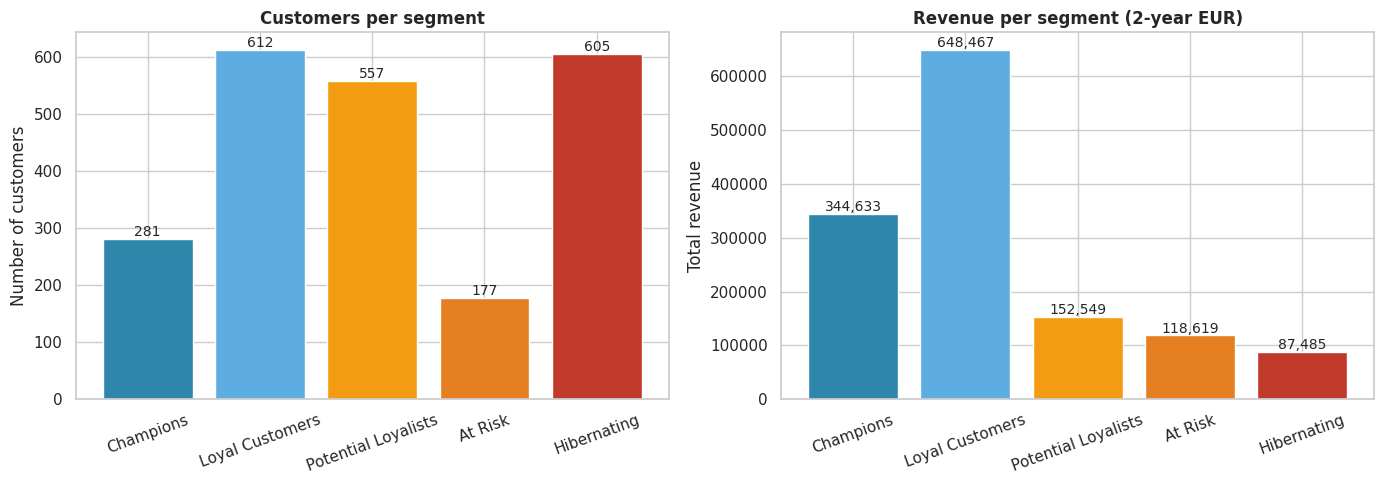

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {"Champions": "#2E86AB", "Loyal Customers": "#5DADE2",
           "Potential Loyalists": "#F39C12", "At Risk": "#E67E22",
           "Hibernating": "#C0392B"}

sizes = segment_profile["Customers"].reindex(segment_order)
revenue = segment_profile["Total_Revenue"].reindex(segment_order)

axes[0].bar(sizes.index, sizes.values, color=[palette[s] for s in sizes.index])
axes[0].set_title("Customers per segment", weight="bold")
axes[0].set_ylabel("Number of customers")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(sizes.values):
    axes[0].text(i, v + 5, f"{int(v):,}", ha="center", fontsize=10)

axes[1].bar(revenue.index, revenue.values, color=[palette[s] for s in revenue.index])
axes[1].set_title("Revenue per segment (2-year EUR)", weight="bold")
axes[1].set_ylabel("Total revenue")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(revenue.values):
    axes[1].text(i, v + 5000, f"{int(v):,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


---
# Task D - Unsupervised Learning (Cluster Analysis)



## D.1 Feature matrix and preprocessing


In [54]:
cluster_features_num = ["Income", "Age", "Children", "Recency", "TotalSpend",
                        "TotalPurchases", "NumWebVisitsMonth", "AcceptedCmpTotal"] + mnt_cols + purchase_cols
cluster_features_cat = ["Education", "Marital_Status"]

X_num = df_clean[cluster_features_num].copy()
X_cat = pd.get_dummies(df_clean[cluster_features_cat], drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)
X.index = df_clean["ID"].values

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print(f"Feature matrix shape: {X_scaled.shape}")


Feature matrix shape: (2232, 26)


## D.2 Choosing K - Elbow + Silhouette


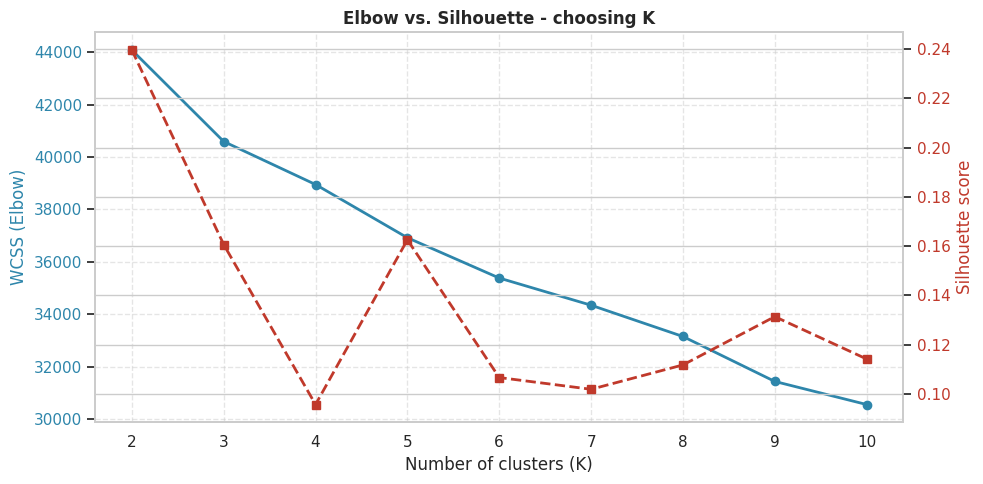

,K,WCSS,Silhouette
0,2,44078.0,0.240
1,3,40590.0,0.161
2,4,38949.0,0.096
3,5,36919.0,0.163
4,6,35382.0,0.107
5,7,34345.0,0.102
6,8,33152.0,0.112
7,9,31438.0,0.131
8,10,30557.0,0.114


In [55]:
K_range = range(2, 11)
wcss = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(list(K_range), wcss, marker="o", color="#2E86AB", linewidth=2, label="WCSS")
ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("WCSS (Elbow)", color="#2E86AB")
ax1.tick_params(axis="y", labelcolor="#2E86AB")
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(list(K_range), silhouettes, marker="s", color="#C0392B",
         linewidth=2, linestyle="--", label="Silhouette")
ax2.set_ylabel("Silhouette score", color="#C0392B")
ax2.tick_params(axis="y", labelcolor="#C0392B")

plt.title("Elbow vs. Silhouette - choosing K", weight="bold")
fig.tight_layout()
plt.show()

pd.DataFrame({"K": list(K_range), "WCSS": np.round(wcss, 0),
              "Silhouette": np.round(silhouettes, 3)})


**Decision.** WCSS keeps decreasing smoothly with no sharp elbow. The silhouette score, however, gives a clear signal: it **drops sharply at K = 4** (0.10) and **rebounds at K = 3 and K = 5** (0.16 each).

Between K = 3 and K = 5, both achieve the same silhouette score. I pick **K = 3** because:

- the WCSS curve has already flattened by K = 3 (the steep drop happens between K = 2 and K = 3),
- three segments are operationally clean for a marketing organization to action - the canonical "high-value / mid-value / low-engagement" split,
- adding two more clusters at K = 5 would not improve cluster quality and would complicate downstream messaging without analytical justification.


In [56]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df_clean["Cluster"] = cluster_labels
rfm["Cluster"] = cluster_labels

print(f"Final K = {optimal_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.3f}")
print(df_clean["Cluster"].value_counts().sort_index())


Final K = 3
Silhouette score: 0.161
Cluster
0    1055
1     573
2     604
Name: count, dtype: int64


## D.3 2D visualization - PCA


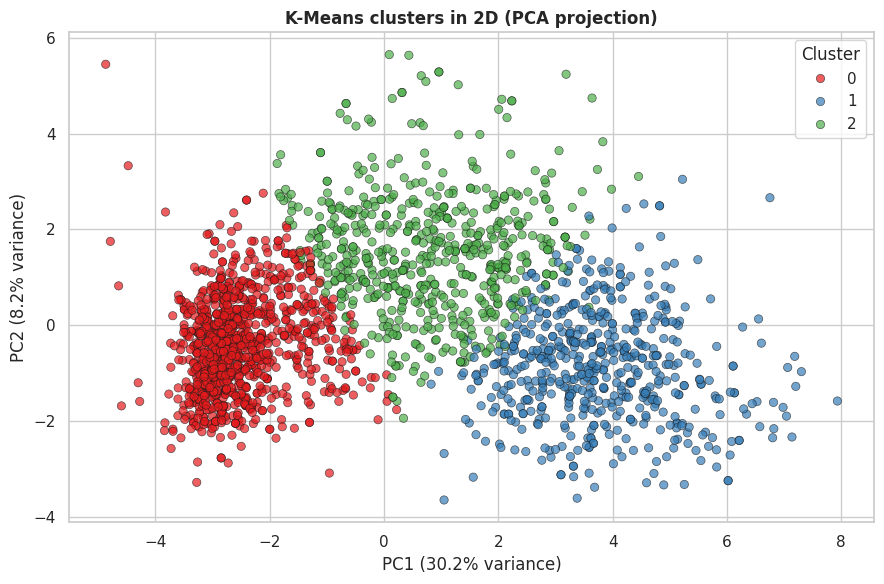

In [57]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels,
                palette="Set1", alpha=0.7, edgecolor="k", legend="full")
plt.title("K-Means clusters in 2D (PCA projection)", weight="bold")
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## D.4 Cluster profiling


In [58]:
profile_num = df_clean.groupby("Cluster").agg(
    Size=("ID", "count"),
    Avg_Income=("Income", "mean"),
    Avg_Age=("Age", "mean"),
    Avg_Children=("Children", "mean"),
    Avg_Recency=("Recency", "mean"),
    Avg_TotalSpend=("TotalSpend", "mean"),
    Avg_TotalPurchases=("TotalPurchases", "mean"),
    Avg_WebVisits=("NumWebVisitsMonth", "mean"),
    Avg_CmpAccepted=("AcceptedCmpTotal", "mean"),
).round(1)
profile_num["% of base"] = (profile_num["Size"] / profile_num["Size"].sum() * 100).round(1)
profile_num


,Size,Avg_Income,Avg_Age,Avg_Children,Avg_Recency,Avg_TotalSpend,Avg_TotalPurchases,Avg_WebVisits,Avg_CmpAccepted,% of base
Cluster,,,,,,,,,,
0,1055,35342.7,42.8,1.2,49.3,99.5,7.9,6.4,0.1,47.3
1,573,76173.8,45.7,0.2,50.1,1400.3,20.9,2.9,0.7,25.7
2,604,57930.6,48.6,1.2,48.0,735.8,21.2,5.8,0.3,27.1


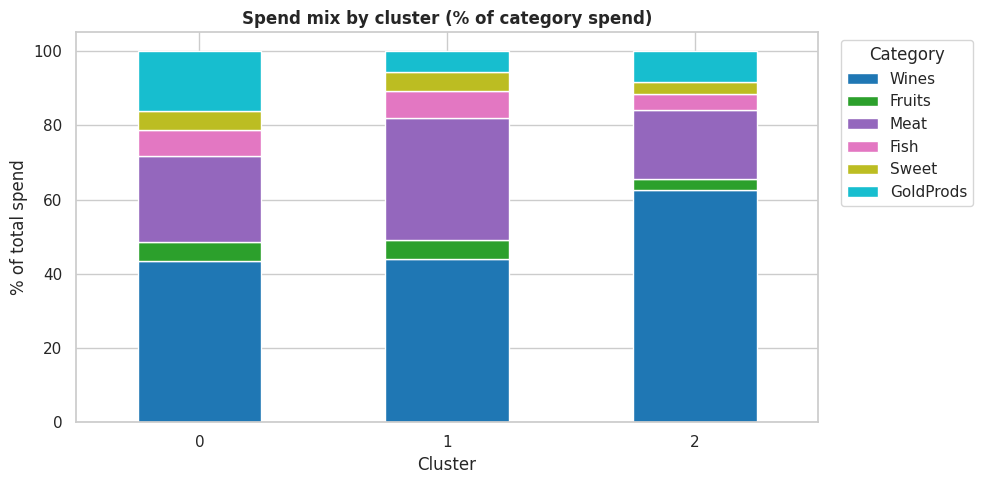

In [59]:
# Spend mix by cluster
spend_mix = df_clean.groupby("Cluster")[mnt_cols].mean().round(0)
spend_mix.columns = [c.replace("Mnt", "").replace("Products", "") for c in spend_mix.columns]
spend_mix_share = spend_mix.div(spend_mix.sum(axis=1), axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(10, 5))
spend_mix_share.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Spend mix by cluster (% of category spend)", weight="bold")
ax.set_ylabel("% of total spend")
ax.set_xlabel("Cluster")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## D.5 Cluster narratives
The profiles are summarized below; the full numerical breakdown is in the cells above.

### Cluster 1 - The Premium Empty-Nesters (~26% of the base, the revenue engine)

The smallest of the three clusters by headcount, but by far the most valuable in revenue terms. Their numerical fingerprint is unambiguous:

- **Highest income** in the dataset (avg ~76K EUR).
- **Effectively childless households** (avg 0.2 children, meaning the vast majority of the cluster has zero kids at home).
- **Highest total spend** - about 1,400 EUR over two years, almost 2x the next cluster and ~14x the lowest cluster.
- **Highest campaign acceptance rate** (0.7 campaigns accepted per customer on average), 2-3x the other clusters.
- Their spend mix is **wine + meat** - the classical signature of premium food and dining. Together these two categories account for over three-quarters of their total spend.

### Cluster 2 - Engaged Family Buyers (~27% of the base, the high-frequency middle)

A middle-income, family-oriented cluster that is more interesting than its size suggests:

- **Mid-tier income** (~58K EUR) and **on average 1.2 children** at home.
- **Mid-tier total spend** (~736 EUR) - about half of Cluster 1.
- **But the highest purchase frequency** in the dataset (~21.2 purchases on average) - technically *higher* than the Empty-Nesters' 20.9. They shop just as often, with smaller baskets per occasion.
- **Wine-dominant spend mix** - wine alone accounts for ~63% of their total spend, the highest wine concentration of any cluster.
- Moderate campaign acceptance and moderate web engagement.

The strategic implication is that this cluster is **already loyal in behavior**, they come back often. The opportunity is to grow basket size, not frequency: cross-sell into adjacent premium categories (meat, fish, gold) and introduce family-bundle promotions that lift average order value.

### Cluster 0 - Budget-Constrained Browsers (~47% of the base, the disengaged majority)

The largest cluster and the one most exposed to wasted marketing spend:

- **Lowest income** (~35K EUR) and **1.2 children** on average.
- **Very low total spend** (~99 EUR over two years) - about 7x less than Cluster 2 and 14x less than Cluster 1.
- **Low purchase frequency** (~8 purchases) but **the highest website-visit frequency** of any cluster (-6.4 visits/month).
- **Lowest campaign acceptance**.

**They browse the most and buy the least**. Pumping more paid traffic to the website will largely feed this cluster, with very weak conversion. The right play is on-site conversion optimization (like deal alerts) and suppression from costly paid acquisition channels.


## D.6 Comparison with RFM segmentation




Crosstab - RFM Segment vs. K-Means Cluster
Cluster                0    1    2
Segment                           
Champions              0  161  120
Loyal Customers        2  276  334
Potential Loyalists  427   54   76
At Risk               71   56   50
Hibernating          555   26   24


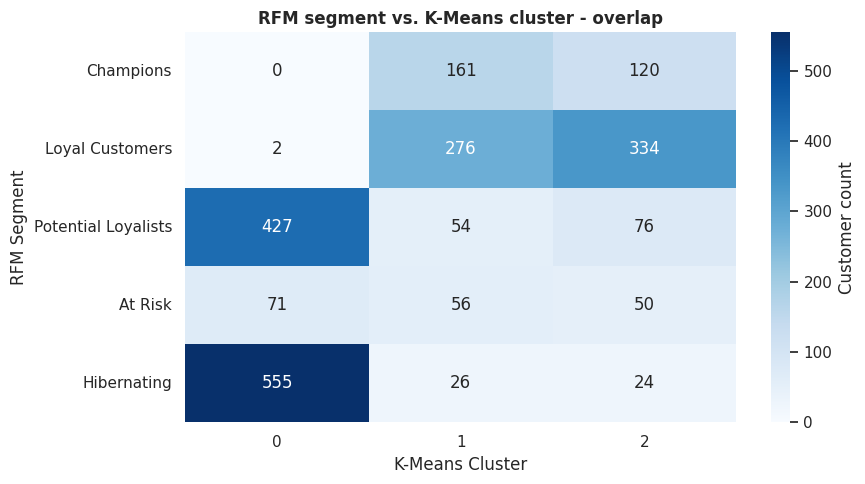

In [60]:
comparison = pd.crosstab(rfm["Segment"], rfm["Cluster"])
print("Crosstab - RFM Segment vs. K-Means Cluster")
print(comparison)

plt.figure(figsize=(9, 5))
sns.heatmap(comparison, annot=True, fmt="d", cmap="Blues",
            cbar_kws={"label": "Customer count"})
plt.title("RFM segment vs. K-Means cluster - overlap", weight="bold")
plt.xlabel("K-Means Cluster")
plt.ylabel("RFM Segment")
plt.tight_layout()
plt.show()


**What each method captures**

The crosstab gives me four observations, each with a different operational implication.

**1. Strong agreement on the extremes.** All 281 RFM Champions sit in the two high-spending clusters - **161 (57%) in the Premium Empty-Nesters and 120 (43%) in the Engaged Family Buyers**, with **literally zero** in the Budget-Constrained Browsers cluster. On the other side, **555 of the 605 Hibernating customers (92%) fall into the Budget Browsers cluster**. The two methods agree completely on *who is great* and *who is gone* - a useful sanity check that both segmentations are picking up real signal.

**2. The "Loyal Customers" disagreement is the real finding.** RFM's Loyal Customers segment (612 customers) splits almost evenly between two clusters: **276 (45%) in Premium Empty-Nesters and 334 (55%) in Engaged Family Buyers**. RFM scores them identically - they all have high frequency and high monetary scores - but the clusters reveal they are **two completely different people**: the first is a wealthy childless household with a 76K average income spending ~1,400 EUR mostly on wine and meat; the second is a middle-income family that shops just as often but with smaller, more wine-concentrated baskets. The communication tone, the cross-sell catalogue, and even the channel they respond to are not the same. **Sending one Loyal-Customer campaign to both groups is a wasted opportunity in either direction.**

**3. RFM's "Potential Loyalists" need a reality check.** This is the finding RFM alone would have hidden. RFM marks 557 customers as Potential Loyalists - bought recently, low frequency so far, "potential to grow into Loyal Customers". But the crosstab shows that **427 of them (77%) are in the Budget-Constrained Browsers cluster**, where average income is 35K, average spend is 99 EUR, web visits are the highest, and campaign acceptance is 0.1. The cluster context strongly suggests these are not future Champions - they are budget-constrained one-time buyers who happened to make a recent small purchase. Treating them with full nurture-the-loyal-customer investment would burn budget.

**4. "At Risk" is a behavior, not a persona.** At Risk customers split evenly across all three clusters (71 / 56 / 50). This makes sense: anyone in any cluster can stop buying. The implication for Task E is that the win-back ladder should be **personalized by cluster**, not one-size-fits-all.


---
# Task E - Communication Strategy

## E.1 Framework

The crosstab in D.6 showed that K-Means and RFM are complementary: **cluster defines channel and tone, RFM defines trigger and offer**. The strategy below uses both axes.

## E.2 Channel and tone by persona

| Persona | Channel | Tone | Content angle |
|---|---|---|---|
| **Premium Empty-Nesters** | Print catalog + curated email | Aspirational, exclusive, no discount language | First-access launches, sommelier wine picks, butcher's selection |
| **Engaged Family Buyers** | Email + push notifications | Warm, conversational, gently incentivized | Wine-paired bundles to grow basket size, family-meal solutions |
| **Budget-Constrained Browsers** | On-site banners + email; suppress paid media | Practical, value-led, time-boxed | Cart-recovery flows, deal alerts, weekday meal ideas |

## E.3 Trigger and offer by RFM segment

| Segment | Trigger | Offer |
|---|---|---|
| **Champions** | Quarterly VIP previews | Recognition, no discount |
| **Loyal Customers** | Monthly cross-sell email | Soft incentive (free shipping, gift-with-purchase) |
| **Potential Loyalists** | Day-7 thank-you, day-30 recommendation | Light-touch - see warning below |
| **At Risk** | Day-60 / day-90 / day-120 voucher ladder | Voucher value scales with cluster's expected LTV |
| **Hibernating** | Quarterly SMS only | Aggressive single-shot deal |

**Warning on Potential Loyalists.** 77% of them sit in the Budget Browsers cluster (see D.6), where campaign acceptance is 0.1. Full nurture investment in this group will not pay back. Reserve nurturing for the 130 Potential Loyalists in the two premium clusters; everyone else gets light-touch only.

**Warning on At Risk.** The voucher must be set by **cluster**, not by RFM label: premium re-engagement for Empty-Nesters, family bundle for Family Buyers, deal voucher for Budget Browsers.
